In [1]:
NUM_AGENTS = 2
HEIGHT = 4
WIDTH = 4
SPAWN_PROB_PER_CELL = 0.05
DESPAWN_PROB_PER_CELL = 0.09

# Parameters
ENV_ITERATIONS = 100000 # 1000000
DISCOUNT = 0.99
EPSILON = 0.1
LEARNING_RATE = 0.00002 # 0.00002
BATCH_SIZE = 32


HIDDEN_FEATURES = 128
HIDDEN_LAYERS = 4
CONV_CHANNELS = [16, 32]
FILENAME = "results.csv"

In [2]:
import sys
sys.path.append("../..")
from models.value_cnn import ValueCNNDecentralized
import numpy as np
from orchard.environment import Action2D, OrchardBasic
from tqdm import tqdm
import torch
from scipy.stats import norm
import copy
import numpy as np
import torch
import matplotlib.pyplot as plt

from models.value_cnn import Transition
from utils import ten_float
from dataclasses import dataclass
from typing import Any
from env_functions import *
from eval_functions import *
import csv
from pathlib import Path


--- PyTorch is configured to use: cuda ---


In [3]:
history = {
    "loss": [],
    "reward_mean": [],
    "reward_std": [],
    "target_mean": [],
    "target_std": [],
    "pred_mean": [],
    "pred_std": [],
    "corr": [],
}

def log_batch_stats(net: ValueCNNDecentralized, batch_size: int):
    """Compute and store one-line summary statistics based on a sample from the replay buffer."""
    with torch.no_grad():
        if len(net.memory) < batch_size:
            return
            
        device = next(net.parameters()).device

        transitions = net.memory.sample(batch_size)
        batch = Transition(*zip(*transitions))

        states = ten_float(np.stack(batch.state), device=device)
        next_states = ten_float(np.stack(batch.new_state), device=device)
        rewards = ten_float(np.array(batch.reward), device=device)

        preds = net.forward(states).squeeze(1)
        
        # CORRECTED: use net.discount instead of net.trainer.discount
        targets = rewards + net.discount * net.target_net(next_states).squeeze(1)

        preds_np, targets_np, rewards_np = preds.cpu().numpy(), targets.cpu().numpy(), rewards.cpu().numpy()
        corr = np.corrcoef(preds_np, targets_np)[0, 1] if len(preds_np) > 1 else np.nan

    history["reward_mean"].append(np.mean(rewards_np))
    history["reward_std"].append(np.std(rewards_np))
    history["target_mean"].append(np.mean(targets_np))
    history["target_std"].append(np.std(targets_np))
    history["pred_mean"].append(np.mean(preds_np))
    history["pred_std"].append(np.std(preds_np))
    history["corr"].append(corr)
def state_to_raw_dict(s: State) -> dict:
    return {"apples": s.apples, "agents": s.agents}



In [4]:
def simulate_step(s: State, agent_idx: int, agent_positions: np.ndarray, action_vector: np.ndarray):
    """
    Simulates an agent taking an action. Does not modify in place.
    
    Returns:
        tuple: (rewards: list[int], next_state: State, new_agent_positions: np.ndarray)
            rewards: List of rewards where rewards[i] is the reward obtained by agent i.
    """
    current_agents = s.agents
    current_apples = s.apples
    idx_pos = agent_positions[agent_idx]
    grid_shape = current_agents.shape
    
    new_idx_pos = np.clip(
        idx_pos + action_vector, [0, 0], np.array(grid_shape) - 1
    )
    
    next_agents = current_agents.copy()
    next_apples = current_apples.copy()
    
    next_agents[tuple(new_idx_pos)] += 1
    next_agents[tuple(idx_pos)] -= 1
    
    # The new positions array must be updated
    new_agent_positions = agent_positions.copy()
    new_agent_positions[agent_idx] = new_idx_pos
    
    rewards = [0 for _ in range(len(agent_positions))]
    if next_apples[tuple(new_idx_pos)] > 0:
        rewards[agent_idx] = -1
        next_apples[tuple(new_idx_pos)] -= 1
        
        picker_pos = new_idx_pos
        sum_of_dist_from_agent_to_picker_pos = 0
        for other_agent_idx, other_agent_pos in enumerate(new_agent_positions):
            dist = np.linalg.norm(other_agent_pos - picker_pos)
            sum_of_dist_from_agent_to_picker_pos += dist
        # assign rewards to other agents
        for other_agent_idx, other_agent_pos in enumerate(new_agent_positions):
            if other_agent_idx != agent_idx:
                dist = np.linalg.norm(other_agent_pos - picker_pos).astype(float)
                if sum_of_dist_from_agent_to_picker_pos > 0:
                    rewards[other_agent_idx] = 2 * (dist / sum_of_dist_from_agent_to_picker_pos)
                else:
                    # this should not happen
                    rewards[other_agent_idx] = 0

    return rewards, State(apples=next_apples, agents=next_agents), new_agent_positions

### Get CNN Estimate Value

In [5]:
def r_team_func(r_list: list):
    return sum(r_list)

In [6]:
s_0 = init_empty_state(HEIGHT, WIDTH)
place_agents_randomly(s_0, NUM_AGENTS)
agent_positions = np.argwhere(s_0.agents == 1)

start_state = s_0.copy()
start_state.name = "Early State"
mid_state = s_0.copy()
mid_state.name = "Mid State"
late_state = s_0.copy()
late_state.name = "Late State"
s_t = s_0.copy()
for t in range(200):
    c = np.random.randint(0, len(agent_positions))
    action = Action2D.get_random_action()
    r_t, s_intermediate, agent_positions = simulate_step(s_t, c, agent_positions, action.vector)
    s_t_plus_1 = s_intermediate.copy()
    spawn_apples(s_t_plus_1, SPAWN_PROB_PER_CELL)
    despawn_apples(s_t_plus_1, DESPAWN_PROB_PER_CELL)
    s_t = s_t_plus_1
    if t == 10:
        start_state = s_t.copy()
        start_state.name = "Early State"
    if t == 50:
        mid_state = s_t.copy()
        mid_state.name = "Mid State"
        
late_state = s_t.copy()
late_state.name = "Late State"
    
states_to_evaluate = [s_0, start_state, mid_state, late_state]
for s in states_to_evaluate:
    print(f"Evaluating state: {s.name}")
    print(s.apples, s.agents)

Evaluating state: Empty State
[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]] [[0 0 1 0]
 [0 0 0 1]
 [0 0 0 0]
 [0 0 0 0]]
Evaluating state: Early State
[[1 0 0 0]
 [0 0 0 0]
 [1 0 1 0]
 [0 0 1 1]] [[0 1 0 1]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]
Evaluating state: Mid State
[[1 1 1 1]
 [0 0 0 0]
 [0 1 1 1]
 [0 0 0 0]] [[0 0 0 0]
 [0 0 1 0]
 [0 0 0 0]
 [0 1 0 0]]
Evaluating state: Late State
[[1 0 0 0]
 [0 1 0 0]
 [0 0 0 0]
 [0 0 1 1]] [[0 0 0 0]
 [0 0 0 0]
 [0 0 1 0]
 [1 0 0 0]]


## DECENTRALIZED INDIVIDUAL MONTE CARLO VALUE ESTIMATION

In [7]:
NUM_TO_AVERAGE_OVER = 100
true_values_per_agent = {} # Using a dict to store results by state name

for state in states_to_evaluate:
    total_values_all_runs = [[] for _ in range(NUM_AGENTS)]
    initial_agent_positions = np.argwhere(state.agents == 1) # This establishes the initial 0/1 index
    
    for _ in tqdm(range(NUM_TO_AVERAGE_OVER), desc=f"Estimating True Value for {state.name}"):
        s_t = state.copy()
        agent_positions = initial_agent_positions.copy()
        
        # Keep track of discounted rewards for each agent index separately
        total_agent_values = [0.0] * NUM_AGENTS
        discount_factor = 1.0
        
        for _ in range(500): # Rollout length
            acting_agent_idx = np.random.randint(0, NUM_AGENTS)
            action = Action2D.get_random_action()
            
            # Use your DECENTRALIZED simulate_step
            r_t_list, s_intermediate, new_agent_positions = simulate_step(
                s_t, acting_agent_idx, agent_positions, action.vector
            )
            s_t_plus_1 = s_intermediate.copy()
            spawn_apples(s_t_plus_1, SPAWN_PROB_PER_CELL)
            despawn_apples(s_t_plus_1, DESPAWN_PROB_PER_CELL)
            
            for i in range(NUM_AGENTS):
                total_agent_values[i] += discount_factor * r_t_list[i]
            
            discount_factor *= DISCOUNT
            s_t = s_t_plus_1
            agent_positions = new_agent_positions
            
        for i in range(NUM_AGENTS):
            total_values_all_runs[i].append(total_agent_values[i])

    # Average over all the rollouts for each agent
    avg_values_for_this_state = [np.mean(vals) for vals in total_values_all_runs]
    true_values_per_agent[state.name] = avg_values_for_this_state
    
    print(f"\nEstimated true individual values for state '{state.name}': {avg_values_for_this_state}")
    print(f"Estimated true TEAM value for state '{state.name}': {sum(avg_values_for_this_state)}\n")

Estimating True Value for Empty State: 100%|██████████| 100/100 [00:01<00:00, 69.74it/s]



Estimated true individual values for state 'Empty State': [np.float64(5.669832060545913), np.float64(5.986281121525236)]
Estimated true TEAM value for state 'Empty State': 11.656113182071149



Estimating True Value for Early State: 100%|██████████| 100/100 [00:01<00:00, 60.90it/s]



Estimated true individual values for state 'Early State': [np.float64(5.962098878059436), np.float64(6.693478193313828)]
Estimated true TEAM value for state 'Early State': 12.655577071373264



Estimating True Value for Mid State: 100%|██████████| 100/100 [00:01<00:00, 69.28it/s]



Estimated true individual values for state 'Mid State': [np.float64(6.174655115723897), np.float64(7.288518216338803)]
Estimated true TEAM value for state 'Mid State': 13.463173332062699



Estimating True Value for Late State: 100%|██████████| 100/100 [00:01<00:00, 69.92it/s]


Estimated true individual values for state 'Late State': [np.float64(5.09214125535239), np.float64(8.005050622591533)]
Estimated true TEAM value for state 'Late State': 13.097191877943922



## TEAM VALUE ESTIMATION

In [8]:
NUM_TO_AVERAGE_OVER = 100
# A new dictionary to store the true team values calculated with decentralized rewards
true_team_values = {} 

print("--- Calculating True TEAM Values using Decentralized Reward Logic ---")
for state in states_to_evaluate:
    total_values = []
    initial_agent_positions = np.argwhere(state.agents == 1)
    
    for _ in tqdm(range(NUM_TO_AVERAGE_OVER), desc=f"Iterating over {state.name}"):
        s_t = state.copy()
        agent_positions = initial_agent_positions.copy()
        total_value = 0.0 # Use float for consistency
        discount_factor = 1.0
        
        for _ in range(1000): # Using 1000 steps to match your centralized notebook
            c = np.random.randint(0, len(agent_positions))
            action = Action2D.get_random_action()
            
            # This is your decentralized simulate_step, which returns a LIST of rewards
            r_t_list, s_intermediate, new_agent_positions = simulate_step(
                s_t, c, agent_positions, action.vector
            )   
            s_t_plus_1 = s_intermediate.copy()
            spawn_apples(s_t_plus_1, SPAWN_PROB_PER_CELL)
            despawn_apples(s_t_plus_1, DESPAWN_PROB_PER_CELL)

            # ** THE ONLY CRITICAL CHANGE IS HERE **
            # Sum the list of rewards to get the team reward for this step
            team_reward_t = r_team_func(r_t_list)

            total_value += discount_factor * team_reward_t
            discount_factor *= DISCOUNT
            s_t = s_t_plus_1
            agent_positions = new_agent_positions
            
        total_values.append(total_value)
        
    avg_value = np.mean(total_values)
    true_team_values[state.name] = avg_value
    print(f"\nEstimated true TEAM value of state '{state.name}': {avg_value}\n")

--- Calculating True TEAM Values using Decentralized Reward Logic ---


Iterating over Empty State: 100%|██████████| 100/100 [00:02<00:00, 37.59it/s]



Estimated true TEAM value of state 'Empty State': 12.211887085258304



Iterating over Early State: 100%|██████████| 100/100 [00:02<00:00, 36.72it/s]



Estimated true TEAM value of state 'Early State': 12.329059309026057



Iterating over Mid State: 100%|██████████| 100/100 [00:03<00:00, 33.25it/s]



Estimated true TEAM value of state 'Mid State': 13.93256744650917



Iterating over Late State: 100%|██████████| 100/100 [00:02<00:00, 35.41it/s]


Estimated true TEAM value of state 'Late State': 12.914633088332359



In [9]:
V_CNNs: list[ValueCNNDecentralized] = []
for _ in range(NUM_AGENTS):
    V_CNNs.append(ValueCNNDecentralized(HEIGHT, WIDTH, LEARNING_RATE, DISCOUNT, 
                                        HIDDEN_FEATURES, HIDDEN_LAYERS, conv_channels=CONV_CHANNELS))
    
s_0 = init_empty_state(HEIGHT, WIDTH)
place_agents_randomly(s_0, NUM_AGENTS)
agent_positions = np.argwhere(s_0.agents == 1)

TARGET_UPDATE_FREQUENCY = 100

total_steps = 0

s_t = s_0.copy()
for t in tqdm(range(ENV_ITERATIONS), desc="Training"):
    c = np.random.randint(0, len(agent_positions))
    
    action = Action2D.get_random_action()
        
    r_D_t_of_c, s_intermediate, new_agent_positions = simulate_step(s_t, c, agent_positions, action.vector)
    s_t_plus_1 = s_intermediate.copy()
    spawn_apples(s_t_plus_1, SPAWN_PROB_PER_CELL)
    despawn_apples(s_t_plus_1, DESPAWN_PROB_PER_CELL)

    for cnn_idx, cnn in enumerate(V_CNNs):
        # c refers to agent c \in C.
        V_CNN_c = cnn
        # 1. Convert states to the network input format
        processed_s_t = V_CNN_c.raw_state_to_nn_input(state_to_raw_dict(s_t), agent_pos=agent_positions[cnn_idx])
        processed_s_t_plus_1 = V_CNN_c.raw_state_to_nn_input(state_to_raw_dict(s_t_plus_1), agent_pos=new_agent_positions[cnn_idx])

        # 2. Add the experience to the replay buffer
        r_idx_D_t_of_c = r_D_t_of_c[cnn_idx]
        V_CNN_c.add_experience(processed_s_t, processed_s_t_plus_1, r_idx_D_t_of_c)

        # 3. Train on a batch ONLY if the buffer is large enough
        if len(V_CNN_c.memory) >= BATCH_SIZE:
            log_batch_stats(V_CNN_c, BATCH_SIZE)
            V_CNN_c.train_batch(BATCH_SIZE)
        
        # 4. Periodically update the target network
        if total_steps % TARGET_UPDATE_FREQUENCY == 0:
            V_CNN_c.update_target_net()

    s_t = s_t_plus_1
    agent_positions = new_agent_positions
    total_steps += 1




Training: 100%|██████████| 100000/100000 [23:06<00:00, 72.11it/s] 


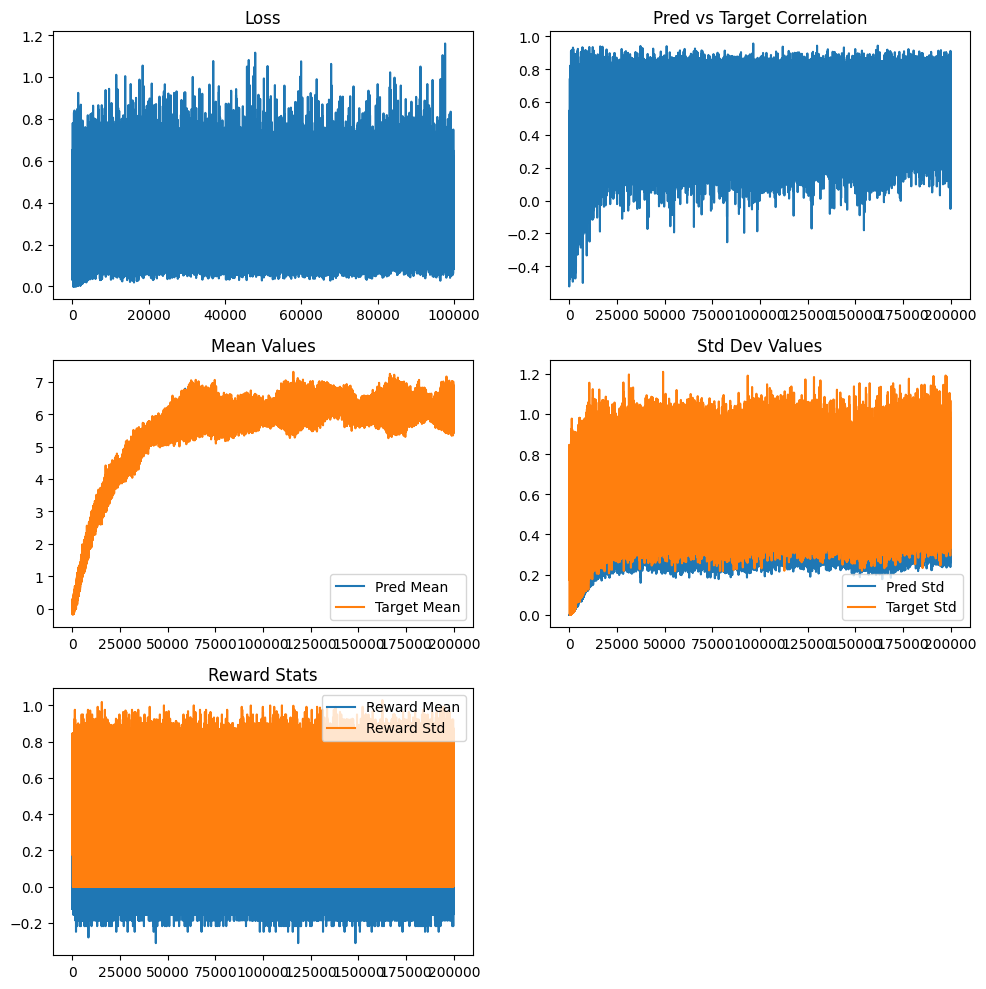

In [10]:
def plot_training_diagnostics(cnn):
    fig, axs = plt.subplots(3, 2, figsize=(10, 10))
    axs = axs.flatten()

    axs[0].plot(cnn.loss_history)
    axs[0].set_title("Loss")

    axs[1].plot(history["corr"])
    axs[1].set_title("Pred vs Target Correlation")

    axs[2].plot(history["pred_mean"], label="Pred Mean")
    axs[2].plot(history["target_mean"], label="Target Mean")
    axs[2].set_title("Mean Values")
    axs[2].legend()

    axs[3].plot(history["pred_std"], label="Pred Std")
    axs[3].plot(history["target_std"], label="Target Std")
    axs[3].set_title("Std Dev Values")
    axs[3].legend()

    axs[4].plot(history["reward_mean"], label="Reward Mean")
    axs[4].plot(history["reward_std"], label="Reward Std")
    axs[4].set_title("Reward Stats")
    axs[4].legend()

    axs[5].axis("off")
    plt.tight_layout()
    plt.show()

plot_training_diagnostics(V_CNN_c)


In [11]:
# --- STEP 2: Verify the trained networks ---
for state in states_to_evaluate:
    print(f"--- Predictions for State: {state.name} ---")
    
    state_positions = np.argwhere(state.agents == 1)
    true_vals = true_values_per_agent[state.name]
    
    predicted_team_value = 0.0
    for agent_idx in range(NUM_AGENTS):
        predicted_val = V_CNNs[agent_idx].get_model_reward_prediction_from_raw(
            state_to_raw_dict(state), 
            agent_pos=state_positions[agent_idx]
        ).item()
        
        predicted_team_value += predicted_val
        
        print(f"  Agent {agent_idx}:")
        print(f"    True Value      ≈ {true_vals[agent_idx]:.4f}")
        print(f"    Predicted Value ≈ {predicted_val:.4f}")

    print(f"\n  TEAM VALUE:")
    print(f"    True Team Value      ≈ {sum(true_vals):.4f}")
    print(f"    Predicted Team Value ≈ {predicted_team_value:.4f}")
    print("-" * 40)

--- Predictions for State: Empty State ---
  Agent 0:
    True Value      ≈ 5.6698
    Predicted Value ≈ 6.1564
  Agent 1:
    True Value      ≈ 5.9863
    Predicted Value ≈ 5.4022

  TEAM VALUE:
    True Team Value      ≈ 11.6561
    Predicted Team Value ≈ 11.5586
----------------------------------------
--- Predictions for State: Early State ---
  Agent 0:
    True Value      ≈ 5.9621
    Predicted Value ≈ 6.3491
  Agent 1:
    True Value      ≈ 6.6935
    Predicted Value ≈ 5.7843

  TEAM VALUE:
    True Team Value      ≈ 12.6556
    Predicted Team Value ≈ 12.1334
----------------------------------------
--- Predictions for State: Mid State ---
  Agent 0:
    True Value      ≈ 6.1747
    Predicted Value ≈ 6.2397
  Agent 1:
    True Value      ≈ 7.2885
    Predicted Value ≈ 6.6609

  TEAM VALUE:
    True Team Value      ≈ 13.4632
    Predicted Team Value ≈ 12.9006
----------------------------------------
--- Predictions for State: Late State ---
  Agent 0:
    True Value      ≈ 5.0921